# Part 3: Can We Rescue v-Prediction?

In [7]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import src.dataloader as dl

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [2]:
OUT_DIR = Path("res/part3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Baseline

### Helpers

In [19]:
def scatter_plot(generated, truth=None, title="Scatter Plot",
                 save_path=None, show=True):
    fig = plt.figure(figsize=(8, 6))
    if truth is not None:
        plt.scatter(truth[:, 0], truth[:, 1],
                    alpha=0.3, s=10, c="gray", label="ground truth")
    plt.scatter(generated[:, 0], generated[:, 1],
                alpha=0.6, s=10, c="C0", label="generated")
    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.gca().set_aspect("equal")
    plt.legend(loc="upper right", framealpha=0.9)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"saved -> {save_path}")
    if show:
        plt.show()
    plt.close(fig)

def generate_samples(model, D, pred_type, device, n=N_GEN):
    denoiser = Denoiser(model, steps=STEPS, D=D)
    return denoiser.generate(n, pred_type, device).cpu().numpy()


def get_ground_truth(dataset, D, n=N_GEN):
    loader = get_dataloader(name=dataset, dim=D, batch_size=n)
    return next(iter(loader))[:n].cpu().numpy()


def project_to_2d(samples, dataset, D):
    if D == 2:
        return samples
    loader = get_dataloader(name=dataset, dim=D, batch_size=1)
    return loader.dataset.to_2d(torch.from_numpy(samples)).numpy()

def sliced_wasserstein(x, y, n_proj=64, seed=0):
    """Sliced Wasserstein-1 distance between two point clouds. Lower = closer."""
    rng = np.random.default_rng(seed)
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    dirs = rng.normal(size=(n_proj, x.shape[1])).astype(np.float64)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    px = np.sort(x @ dirs.T, axis=0)              # (n, n_proj)
    py = np.sort(y @ dirs.T, axis=0)
    return float(np.mean(np.abs(px - py)))

In [20]:
device = torch.device('cuda')

In [21]:
N_GEN = 2048
dataset = "swiss_roll"
D = 32
bsz = 1024
train_steps = 25000
STEPS = 50
pred = 'v'
loss = 'v'

In [22]:
# Dataloader
dataloader = get_dataloader(name=dataset, dim=D, batch_size=bsz)
# MLP Model
model = JiM(hidden_dim=256, D=D)
model = model.to(device)
# Optimiser
opt = optim.Adam(model.parameters(), lr=1e-3)
# Train
loss = train_n_steps(model, dataloader, opt, device, train_steps, pred_type=pred, loss_type=loss)

step    500/25000  loss 0.309473
step   1000/25000  loss 0.133676
step   1500/25000  loss 0.120883
step   2000/25000  loss 0.115999
step   2500/25000  loss 0.111540
step   3000/25000  loss 0.102511
step   3500/25000  loss 0.097951
step   4000/25000  loss 0.095859
step   4500/25000  loss 0.093039
step   5000/25000  loss 0.091557
step   5500/25000  loss 0.090428
step   6000/25000  loss 0.089363
step   6500/25000  loss 0.088116
step   7000/25000  loss 0.087443
step   7500/25000  loss 0.086291
step   8000/25000  loss 0.086014
step   8500/25000  loss 0.084988
step   9000/25000  loss 0.084638
step   9500/25000  loss 0.084471
step  10000/25000  loss 0.083099
step  10500/25000  loss 0.083150
step  11000/25000  loss 0.082099
step  11500/25000  loss 0.081700
step  12000/25000  loss 0.081524
step  12500/25000  loss 0.080832
step  13000/25000  loss 0.081054
step  13500/25000  loss 0.080481
step  14000/25000  loss 0.080264
step  14500/25000  loss 0.079934
step  15000/25000  loss 0.079547
step  1550

saved -> res/part3/swiss_roll_JiM.png


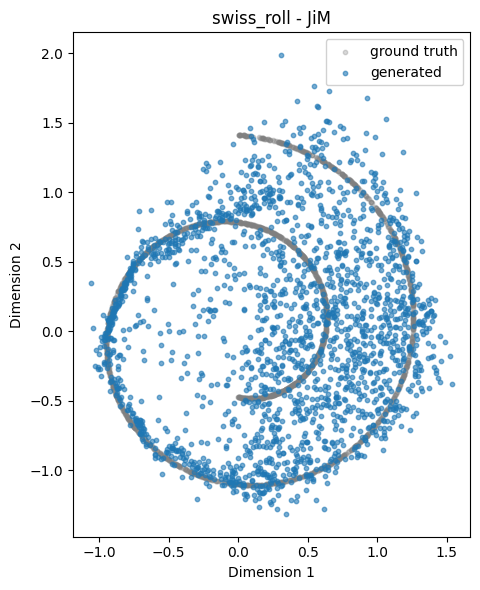

swd=0.0944434715931642


In [23]:
# Generate
gen = generate_samples(model, D, pred, device)
gt = get_ground_truth(dataset, D)


gen2d = project_to_2d(gen, dataset, D)
gt2d = project_to_2d(gt, dataset, D)

scatter_plot(gen2d, gt2d, title=f"{dataset} - JiM" , save_path=OUT_DIR / f"{dataset}_JiM.png",)

swd = sliced_wasserstein(gen2d, gt2d)
print(f"swd={swd}")